In [65]:
## Import libraries
import numpy as np
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import PPO
from IPython.display import clear_output

## Import custom modules
import sys
import os
# Append the parent directory to the sys.path
this_path = os.path.abspath('') 
parent_dir = os.path.dirname(this_path)  
sys.path.append(parent_dir)
from modules import bot_utils as bu, utils

### Kernels

In [66]:
kernel_worms = np.array([[0.68, -0.9, 0.68], 
                        [-0.9, -0.66,  -0.9], 
                        [0.68,  -0.9, 0.68]])

### Parameters

In [67]:
var1 = 0.3
var2 = 0.3
var_th = 1e-4
var_min = 0.7
var_max = 1.0
n_objects_min = 50
n_objects_max = 1000
n_objects_min_transformed = np.tanh(n_objects_min/1000.)
n_objects_max_transformed = np.tanh(n_objects_max/1000.)
#observation_boundaries = np.array([[n_objects_min_transformed, n_objects_max_transformed]])
observation_boundaries = np.array([[var_min, var_max]])
lows = observation_boundaries[:, 0]
highs = observation_boundaries[:, 1]
desiderata = np.random.uniform(low=lows, high=highs).astype(np.float32)
kernel_size = 3
f_symm = True
h_symm = False
v_symm = False
hv_symm = h_symm and v_symm
fixed_center = False
activation = 'identity'
kernel_prec = 3
scale_kernel = False
t_max = 500
mid_timesteps = t_max
pixel_lbound = -1
pixel_ubound = 1
edge_len = 250
periodic = False

ent_coef = 10.
lr = 0.01

# Number of free parameters
n_free_parameters = utils.n_free_parameters(f_symm=f_symm, 
                                            hv_symm=hv_symm, 
                                            h_symm=h_symm, 
                                            v_symm=v_symm, 
                                            kernel_size=kernel_size,
                                            fixed_center=fixed_center)
print("Number of free parameters:", n_free_parameters)
print("Desiderata:", desiderata)
print("Observation boundaries", observation_boundaries)
print("Variance threshold", var_th)

Number of free parameters: 3
Desiderata: [0.88207906]
Observation boundaries [[0.7 1. ]]
Variance threshold 0.0001


### Env

In [68]:
bot = bu.Bot(kernel_size=kernel_size,
             #kernel=kernel_worms,
             f_symm=f_symm,
             h_symm=h_symm, 
             v_symm=v_symm, 
             fixed_center=fixed_center,
             activation=activation, 
             kernel_prec=kernel_prec,
             scale_kernel=scale_kernel)
rewarder = bu.Rewarder(desiderata=desiderata, 
                        scales=(5, 30))
env = bu.Environment(bot=bot,
                     n_free_parameters=n_free_parameters,
                     observation_boundaries=observation_boundaries,
                     max_timesteps=t_max,
                     rewarder=rewarder, 
                     edge_len=edge_len,
                     mid_timesteps=mid_timesteps, 
                     var_th=var_th, 
                     pixel_lbound=pixel_lbound, 
                     pixel_ubound=pixel_ubound)

In [69]:
check_env(env)

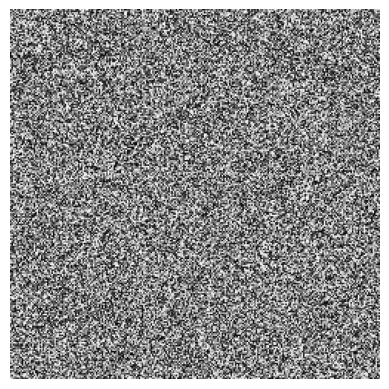

(0.3308751963208949, 1.6726938169250867)

In [70]:
env.reset()
utils.display_image(env.image, vmin=0, vmax=255)
state = utils.image_to_state(env.image)
rewarder.update(state)
rewarder.compute_variance(state), rewarder.reward

### Train policy model

In [71]:
log_dir = "./ppo_logs/"
os.makedirs(log_dir, exist_ok=True)  

In [72]:
print('Learning rate: %.2f'%lr)
model = PPO("MlpPolicy", 
            env, 
            verbose=1, 
            n_steps=200, 
            batch_size=50,
            learning_rate=lr,
            #ent_coef=ent_coef,
            tensorboard_log=log_dir)
model.learn(total_timesteps=10000)

Learning rate: 0.01
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./ppo_logs/PPO_11
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | 18       |
| time/              |          |
|    fps             | 2        |
|    iterations      | 1        |
|    time_elapsed    | 67       |
|    total_timesteps | 200      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | 32.4        |
| time/                   |             |
|    fps                  | 2           |
|    iterations           | 2           |
|    time_elapsed         | 133         |
|    total_timesteps      | 400         |
| train/                  |             |
|    approx_kl            | 0.040448613 |
|    clip_fraction        | 0.263       |
|    clip_ran

### Dynamics

In [2]:
#n_object = 10 #120
#n_objects_transformed = np.tanh(n_object/1000.)
#desiderata = np.array([n_objects_transformed]) # np.array([var1, var2, n_objects_transformed])
#desiderata = np.random.uniform(low=lows, high=highs).astype(np.float32)
desiderata = np.array([0.95])
print('Desiderata:', desiderata)
parameters, _states = model.predict(desiderata)
a = .4
#parameters = np.array([a, a])
print('Parameters:', parameters)

NameError: name 'np' is not defined

kernel:
 [[ 1.     1.     1.   ]
 [ 1.    -0.187  1.   ]
 [ 1.     1.     1.   ]]
desiderata: [0.95]
observation: [0.97995144]
reward: 33.38737504226789
n. objects: 41


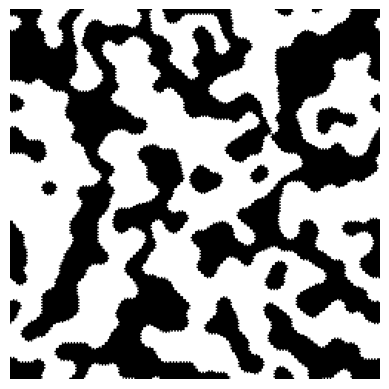

1000


In [ ]:
bot.update_kernel(parameters)
env = bu.Environment(bot=bot,
                     n_free_parameters=n_free_parameters,
                     observation_boundaries=observation_boundaries,
                     max_timesteps=1000,
                     mid_timesteps=20,
                     rewarder=rewarder, 
                     edge_len=edge_len,
                     var_th=var_th, 
                     pixel_lbound=pixel_lbound, 
                     pixel_ubound=pixel_ubound)

env.reset(desiderata=desiderata)

terminated = False
while not terminated:
    terminated, info = env.step_eval()
    utils.display_image(env.image) #, vmin=1, vmax=255)
    clear_output(wait=True)

print('kernel:\n', bot.kernel)
for key, value in info.items():
    print(f"{key}: {value}")
print('n. objects:', rewarder.count_objects(env.image))
utils.display_image(env.image) #, vmin=1, vmax=255)
print(env.timestep)